In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

from delphi.grad import TruncatedMultivariateNormalNLL

import torch as ch
import matplotlib.pyplot as plt
%matplotlib notebook
import numpy as np
from torch.distributions import MultivariateNormal

In [2]:
# === Ground truth parameters ===
dims = 1
true_mu = ch.ones(dims)
true_var = ch.eye(dims)
true_T = ch.inverse(true_var)
true_v = true_T @ true_mu

print(f'true mean: {true_mu.tolist()}')
print(f'true covariance: {true_var.tolist()}')

true mean: [1.0]
true covariance: [[1.0]]


In [9]:
# === Synthetic truncated dataset ===
dist = MultivariateNormal(true_mu, true_var)
samples = dist.sample((5000,))
# Define truncation region: S = {z > 0}
def phi(z):
    return (z[..., 0] > 0)
S = samples[phi(samples)]
S_grad = ch.zeros_like(S)
data = ch.cat([S, S_grad], dim=1)

x_obs = samples.mean(0, keepdim=True) # empirical mean as observed sample
print(f"Observed mean (x): {x_obs.tolist()}")

Observed mean (x): [[0.9833480715751648, 1.01554536819458]]


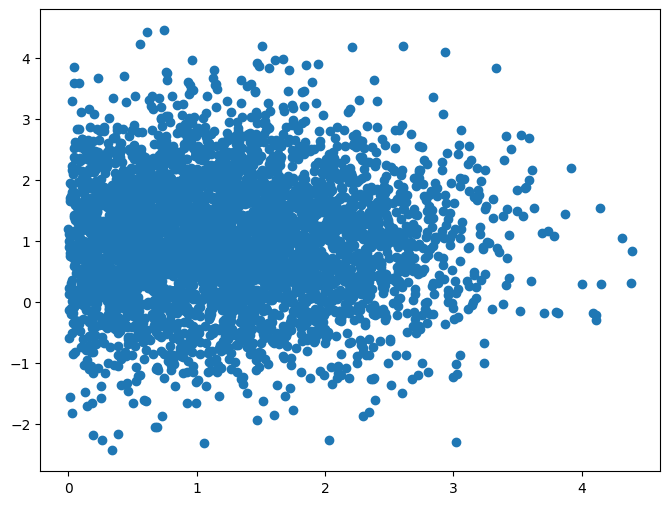

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(S[:,0], S[:,1])

In [40]:
# === Dummy context and censored tracker ===
censored_sample_nll = ch.tensor(0.0)

# === Function to compute loss for a given μ and σ ===
def trunc_nll(params):
#     mu = mu_val.float()
#     Sigma = ch.tensor([[sigma_val ** 2]]).float()
    
#     T = ch.inverse(Sigma)
#     v = T @ mu
#     params = ch.cat([T.flatten(), v])
    loss = TruncatedMultivariateNormalNLL.apply(
        params, data, phi, dims, censored_sample_nll, None, 10000
    )
    return loss.item()

# === Parameter grids ===
mu_values = np.linspace(-1.0, 3.0, 20)
sigma_values = np.linspace(0.5, 2.0, 20)
MU, SIGMA = np.meshgrid(mu_values, sigma_values)

# === Compute NLL over the grid ===
Z = np.zeros_like(MU)
for i in range(len(sigma_values)):
    for j in range(len(mu_values)):
        Z[i, j] = trunc_nll(MU[i, j], SIGMA[i, j])

# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
cp = ax1.contourf(MU, SIGMA, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Gaussian NLL Landscape")
ax1.set_xlabel("μ value")
ax1.set_ylabel("σ value")

# mark the ground truth
ax1.plot(true_mu.item(), true_var.sqrt().item(), 'rx', markersize=10, label="True parameters")
ax1.legend()

mus = ch.linspace(-2, 3, 30)
losses = [trunc_nll(ch.tensor([m]), true_var) for m in mus]

ax2.plot(mus, losses)
ax2.set_xlabel("μ value")
ax2.set_ylabel("Negative log-likelihood")
ax2.set_title("Truncated Gaussian NLL vs μ")
plt.show()

TypeError: trunc_nll() takes 1 positional argument but 2 were given

Ground truth: μ=1.000, σ=1.000
Minimum found: μ=0.931, σ=1.017, loss=1.104

Loss at ground truth: 1.101
Loss at minimum: 1.104
Difference: -0.002


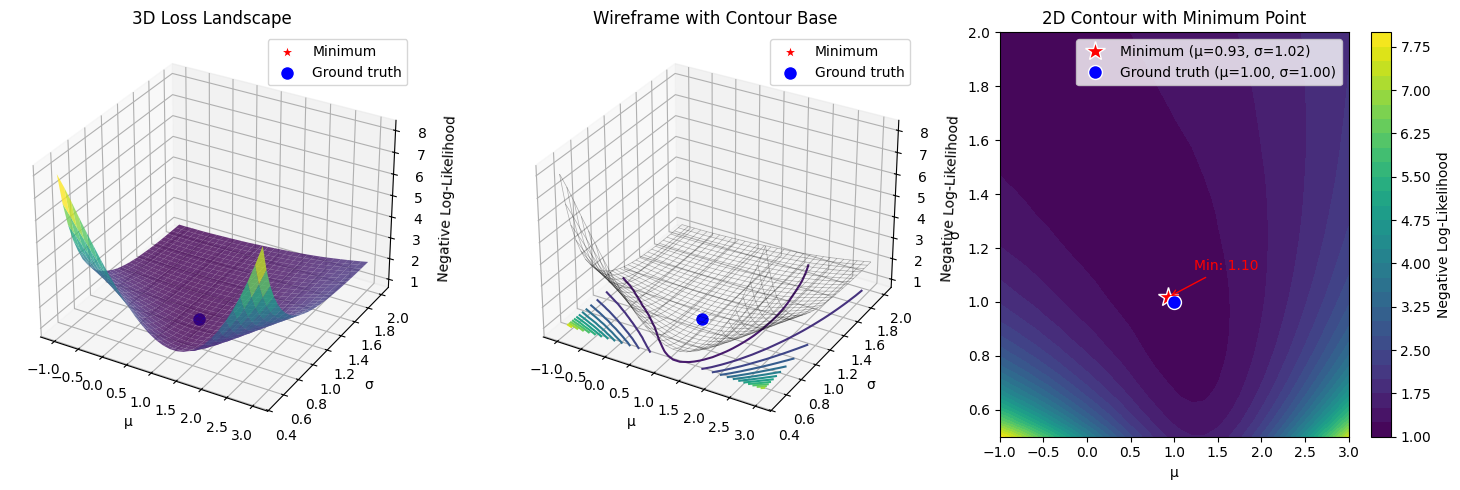

In [5]:
# === Parameter grids ===
mu_values = np.linspace(-1.0, 3.0, 30)  # Increased resolution
sigma_values = np.linspace(0.5, 2.0, 30)
MU, SIGMA = np.meshgrid(mu_values, sigma_values)

# === Compute NLL over the grid ===
Z = np.zeros_like(MU)
for i in range(len(sigma_values)):
    for j in range(len(mu_values)):
        Z[i, j] = trunc_nll(MU[i, j], SIGMA[i, j])

# Find the minimum point
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
min_mu = MU[min_idx]
min_sigma = SIGMA[min_idx]
min_loss = Z[min_idx]

print(f"Ground truth: μ={true_mu.item():.3f}, σ={true_var.sqrt().item():.3f}")
print(f"Minimum found: μ={min_mu:.3f}, σ={min_sigma:.3f}, loss={min_loss:.3f}")

# === Create 3D visualization ===
fig = plt.figure(figsize=(15, 5))

# Plot 1: 3D surface plot
ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(MU, SIGMA, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax1.scatter([min_mu], [min_sigma], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax1.scatter([true_mu.item()], [true_var.sqrt().item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax1.set_xlabel('μ')
ax1.set_ylabel('σ')
ax1.set_zlabel('Negative Log-Likelihood')
ax1.set_title('3D Loss Landscape')
ax1.legend()

# Plot 2: 3D wireframe plot
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_wireframe(MU, SIGMA, Z, color='black', alpha=0.3, linewidth=0.5)
contour = ax2.contour(MU, SIGMA, Z, levels=15, offset=np.min(Z) - 0.1, cmap='viridis')
ax2.scatter([min_mu], [min_sigma], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax2.scatter([true_mu.item()], [true_var.sqrt().item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax2.set_xlabel('μ')
ax2.set_ylabel('σ')
ax2.set_zlabel('Negative Log-Likelihood')
ax2.set_title('Wireframe with Contour Base')
ax2.legend()

# Plot 3: Heatmap with minimum point
ax3 = fig.add_subplot(133)
contourf = ax3.contourf(MU, SIGMA, Z, levels=30, cmap='viridis')
plt.colorbar(contourf, ax=ax3, label='Negative Log-Likelihood')

# Mark minimum and ground truth
ax3.plot(min_mu, min_sigma, 'r*', markersize=15, markeredgecolor='white', 
        label=f'Minimum (μ={min_mu:.2f}, σ={min_sigma:.2f})')
ax3.plot(true_mu.item(), true_var.sqrt().item(), 'bo', markersize=10, 
        markeredgecolor='white', label=f'Ground truth (μ={true_mu.item():.2f}, σ={true_var.sqrt().item():.2f})')

# Add text annotation for the minimum point
ax3.annotate(f'Min: {min_loss:.2f}', 
            xy=(min_mu, min_sigma), 
            xytext=(min_mu+0.3, min_sigma+0.1),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax3.set_xlabel('μ')
ax3.set_ylabel('σ')
ax3.set_title('2D Contour with Minimum Point')
ax3.legend()

# === Additional analysis ===
print(f"\nLoss at ground truth: {trunc_nll(true_mu.item(), true_var.sqrt().item()):.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {trunc_nll(true_mu.item(), true_var.sqrt().item()) - min_loss:.3f}")

plt.tight_layout()
plt.show()

In [45]:
# === Ground truth parameters ===
dims = 2
true_mu = ch.ones(dims)
true_var = ch.eye(dims)
true_T = ch.inverse(true_var)
true_v = true_T @ true_mu

print(f'true mean: {true_mu.tolist()}')
print(f'true covariance: {true_var.tolist()}')

true mean: [1.0, 1.0]
true covariance: [[1.0, 0.0], [0.0, 1.0]]


Observed mean (x): [[0.991546094417572, 0.9956400394439697]]


<IPython.core.display.Javascript object>


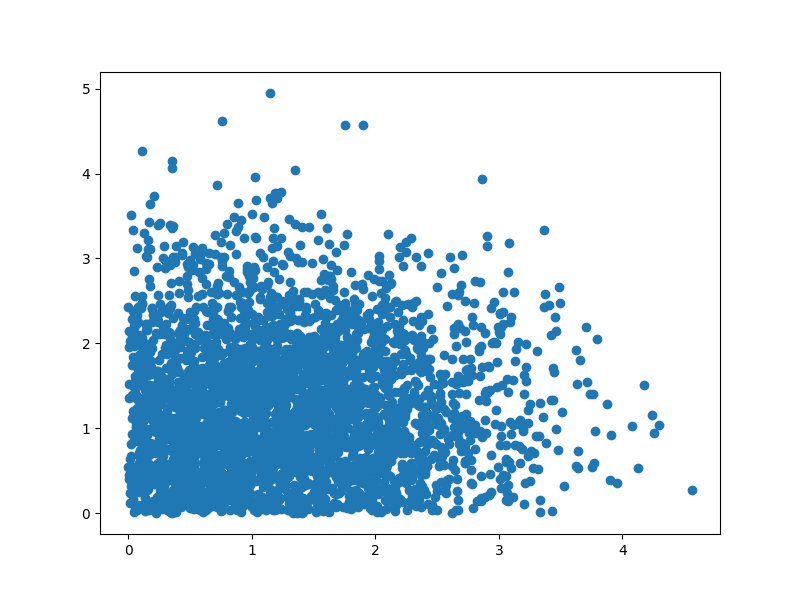

In [46]:
# === Synthetic truncated dataset ===
dist = MultivariateNormal(true_mu, true_var)
samples = dist.sample((5000,))
# === Truncation region ===
def phi(z):
    # Keep only samples where both coordinates > 0
    return (z[:, 0] > 0) & (z[:, 1] > 0)
S = samples[phi(samples)]
S_grad = ch.zeros_like(S)
data = ch.cat([S, S_grad], dim=1)

x_obs = samples.mean(0, keepdim=True) # empirical mean as observed sample
print(f"Observed mean (x): {x_obs.tolist()}")

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(S[:,0], S[:,1])

<IPython.core.display.Javascript object>


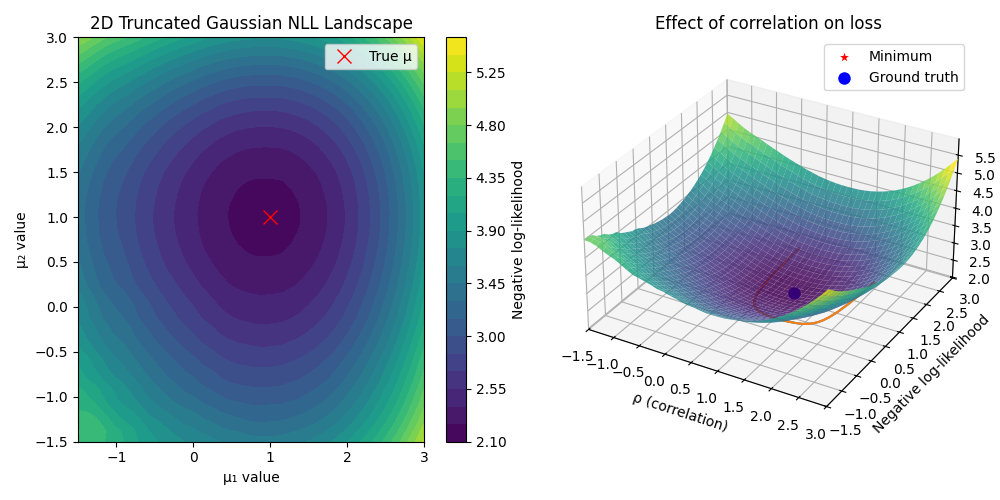

In [25]:
# === Dummy context variables ===
censored_sample_nll = ch.tensor(0.0)

# === Parameter grid for μ₁ and μ₂ ===
mu1_vals = np.linspace(-1.5, 3.0, 40)
mu2_vals = np.linspace(-1.5, 3.0, 40)
MU1, MU2 = np.meshgrid(mu1_vals, mu2_vals)

Z = np.zeros_like(MU1)
for i in range(len(mu2_vals)):
    for j in range(len(mu1_vals)):
        mu_vec = ch.tensor([MU1[i, j], MU2[i, j]])
        Z[i, j] = trunc_nll(mu_vec, true_var)
        
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
min_mu_1, min_mu_2 = MU1[min_idx], MU2[min_idx]
min_loss = Z[min_idx]

fig = plt.figure(figsize=(10, 5))

# === 2D contour plot ===
ax1 = fig.add_subplot(121)
cp = ax1.contourf(MU1, MU2, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("2D Truncated Gaussian NLL Landscape")
ax1.set_xlabel("μ₁ value")
ax1.set_ylabel("μ₂ value")

# mark the ground truth
ax1.plot(true_mu[0].item(), true_mu[1].item(), 'rx', markersize=10, label="True μ")
ax1.legend()

# === 3D surface plot ===
ax2 = fig.add_subplot(122, projection='3d')
surf = ax2.plot_surface(MU1, MU2, Z, cmap='viridis', alpha=0.85,
                        linewidth=0, antialiased=True)

# plot key points
ax2.scatter([min_mu_1], [min_mu_2], [min_loss],
            color='red', s=100, label='Minimum', marker='*', edgecolors='white')
ax2.scatter([true_mu[0].item()], [true_mu[1].item()], [np.min(Z)],
            color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')

# formatting
ax2.set_xlabel('μ₁ value')
ax2.set_ylabel('μ₂ value')
ax2.set_zlabel('Negative Log-Likelihood')
ax2.set_title('3D Loss Landscape')
ax2.legend()

# fix clipping
ax2.set_box_aspect((1, 1, 0.6))  # prevents z from being squashed
ax2.set_xlim(MU1.min(), MU1.max())
ax2.set_ylim(MU2.min(), MU2.max())
ax2.set_zlim(Z.min() - 0.1 * abs(Z.min()), Z.max() + 0.1 * abs(Z.max()))

plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


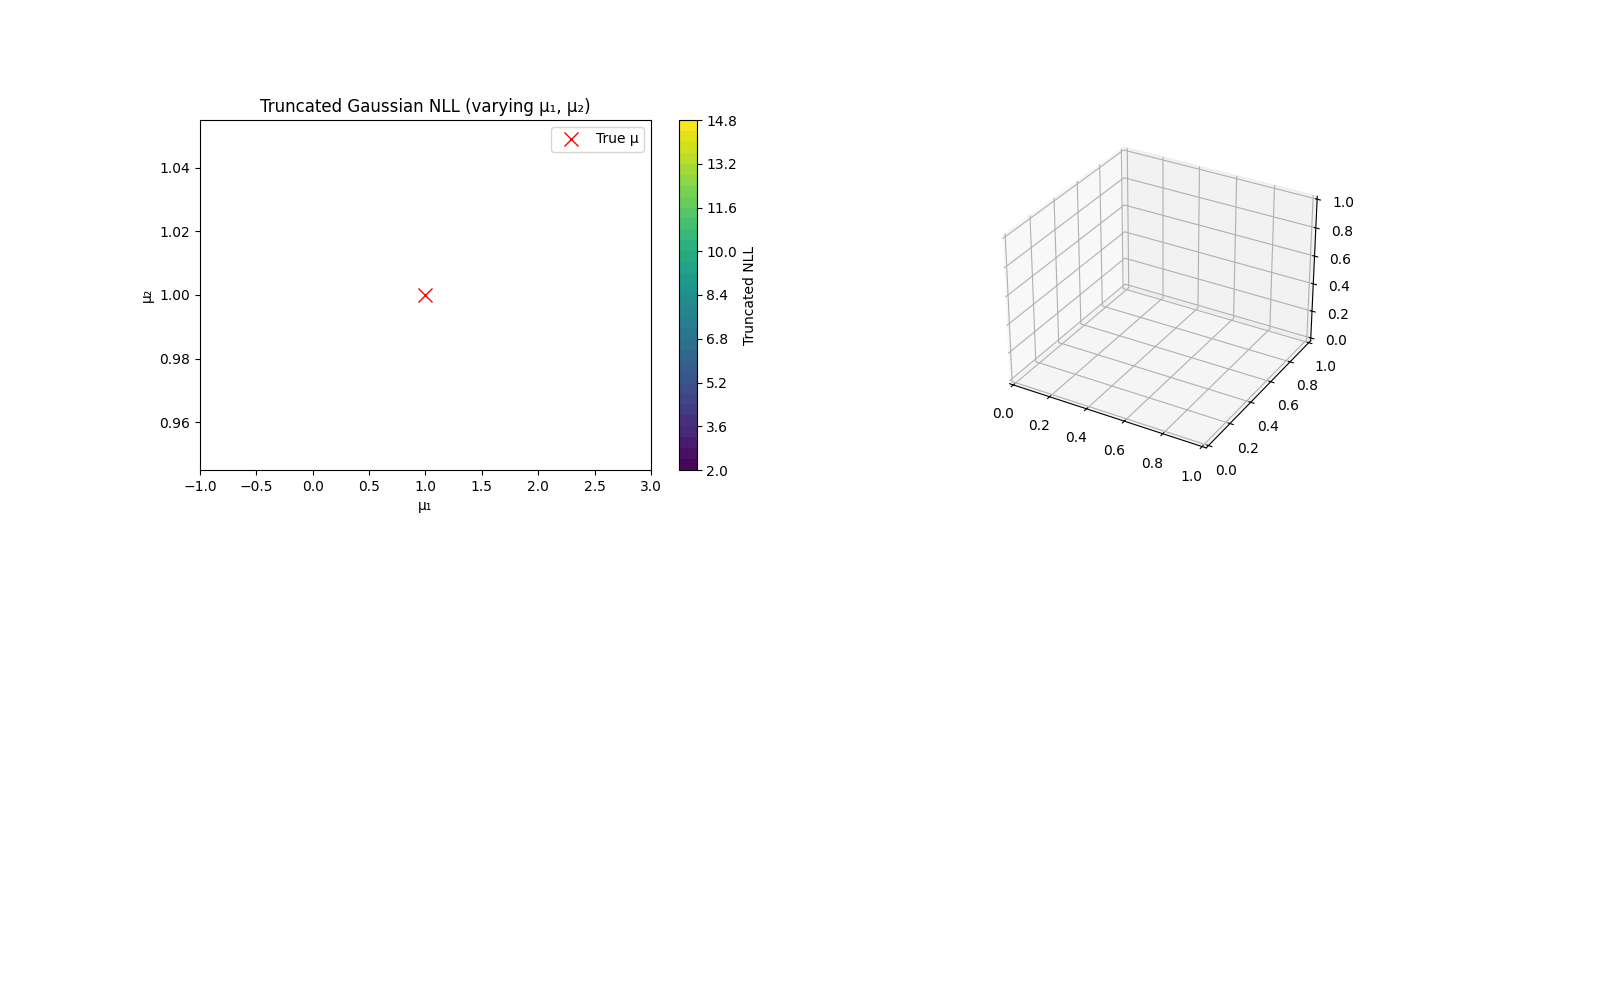

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (30, 30) and arg 1 with shape (40, 40).

In [62]:
# ==== Vary μ₁ and σ₁ (fix μ₂, σ₂) ====
mu1_vals = np.linspace(-1, 3, 30)
sigma1_vals = np.linspace(0.4, 2.0, 30)
MU1, SIGMA1 = np.meshgrid(mu1_vals, sigma1_vals)
Z_mu_sigma = np.zeros_like(MU1)

sigma2_fixed = 1.0

for i in range(len(sigma1_vals)):
    for j in range(len(mu1_vals)):
        mu = ch.tensor([MU1[i, j], true_mu[1]])
        Sigma = ch.diag(ch.tensor([SIGMA1[i, j], sigma2_fixed]) ** 2)
        T = ch.inverse(Sigma)
        v = T @ mu
        params = ch.cat([T.flatten(), v]).float()
        Z_mu_sigma[i, j] = trunc_nll(params)

# ==== Visualization ====
fig = plt.figure(figsize=(16, 10))

# --- 1: varying μ₁, μ₂ ---
ax1 = fig.add_subplot(2, 2, 1)
cp = ax1.contourf(mu1_vals, ch.full([30,], true_mu[1].item()), Z_mu_sigma, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Truncated NLL")
ax1.plot(true_mu[0], true_mu[1], "rx", markersize=10, label="True μ")
ax1.set_title("Truncated Gaussian NLL (varying μ₁, μ₂)")
ax1.set_xlabel("μ₁")
ax1.set_ylabel("μ₂")
ax1.legend()

ax2 = fig.add_subplot(2, 2, 2, projection="3d")
ax2.plot_surface(MU1, MU2, Z_mu, cmap="viridis", alpha=0.8, linewidth=0)
ax2.set_xlabel("μ₁")
ax2.set_ylabel("μ₂")
ax2.set_zlabel("NLL")
ax2.set_title("3D Surface (μ₁, μ₂)")

# --- 2: varying μ₁, σ₁ ---
ax3 = fig.add_subplot(2, 2, 3)
cp = ax3.contourf(mu1_vals, sigma1_vals, Z_mu_sigma, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax3, label="Truncated NLL")
ax3.plot(true_mu[0], 1.0, "rx", markersize=10, label="True params")
ax3.set_title("Truncated Gaussian NLL (varying μ₁, σ₁)")
ax3.set_xlabel("μ₁")
ax3.set_ylabel("σ₁")
ax3.legend()

ax4 = fig.add_subplot(2, 2, 4, projection="3d")
ax4.plot_surface(MU1, SIGMA1, Z_mu_sigma, cmap="viridis", alpha=0.8, linewidth=0)
ax4.set_xlabel("μ₁")
ax4.set_ylabel("σ₁")
ax4.set_zlabel("NLL")
ax4.set_title("3D Surface (μ₁, σ₁)")

plt.tight_layout()
plt.show()

In [65]:
MU2.shape

(40, 40)

In [61]:
mu1_vals.shape

(30,)

Observed mean (x): tensor([[1.2833, 2.0065]])


<IPython.core.display.Javascript object>


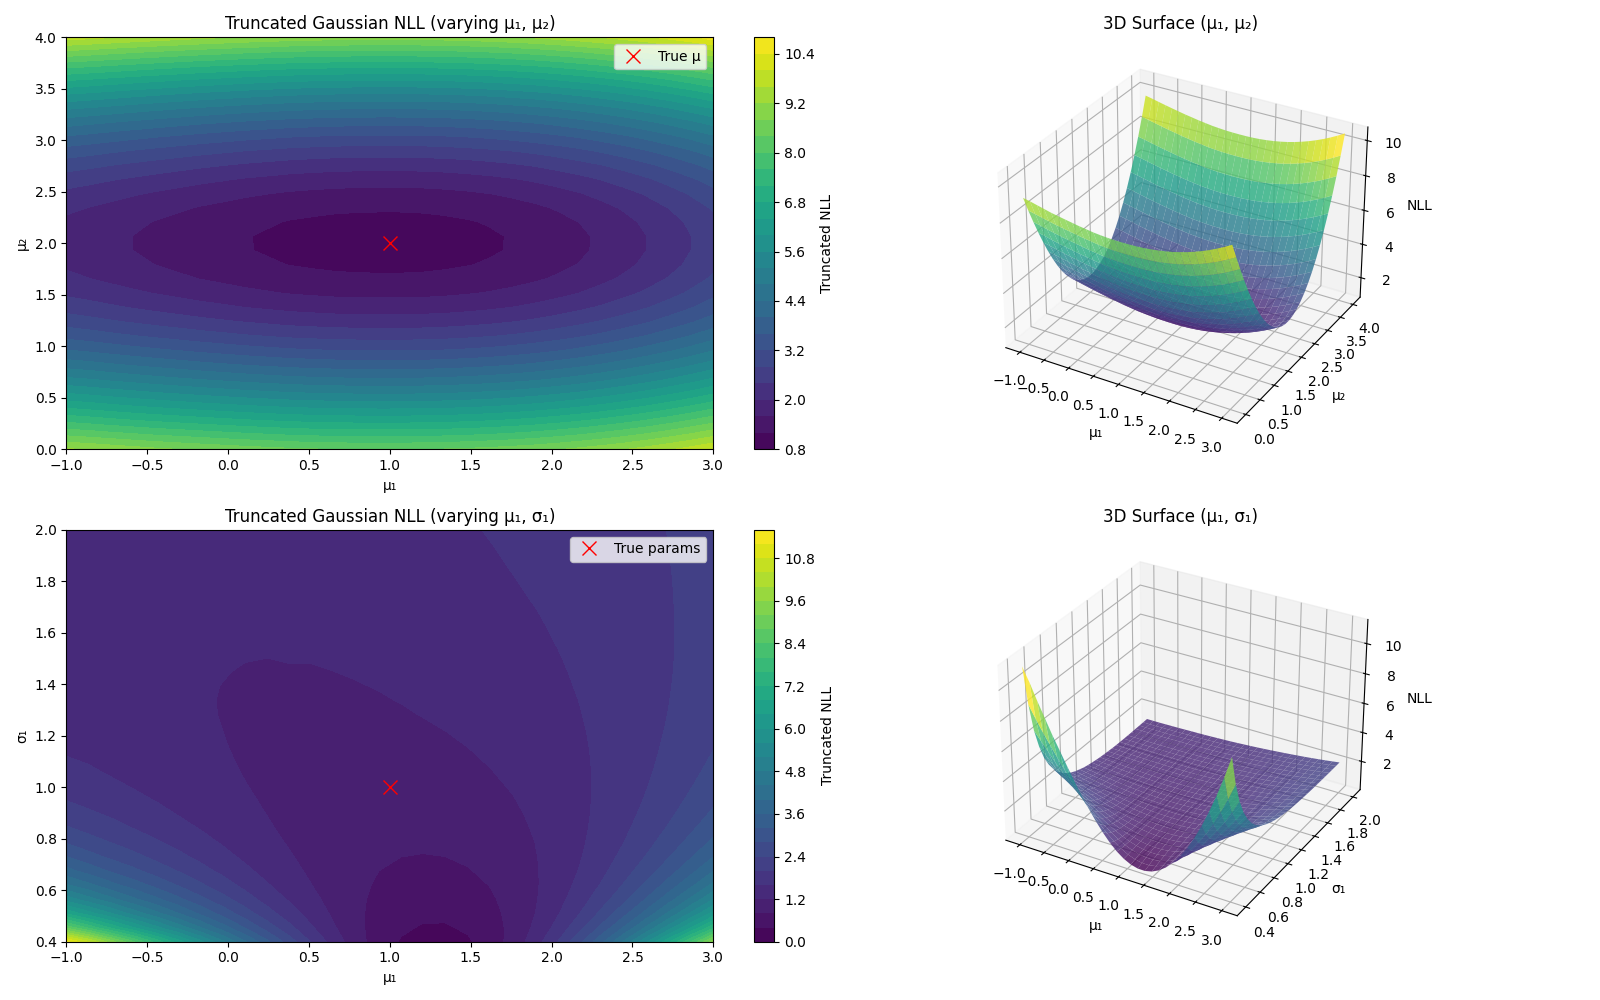

In [72]:
import torch as ch
import matplotlib.pyplot as plt
import numpy as np

# ==== Define truncation region ====
def phi(z):
    # Example: both coordinates must be > 0
    return (z[..., 0] > 0) & (z[..., 1] > 0)

# ==== True distribution parameters ====
true_mu = ch.tensor([1.0, 2.0])
true_sigma = ch.diag(ch.tensor([1.0, 0.5]))  # diagonal covariance
dims = 2

# ==== Generate synthetic truncated data ====
M = ch.distributions.MultivariateNormal(true_mu, true_sigma)
samples = M.sample((10000,))
samples = samples[phi(samples)]  # apply truncation
x_obs = samples.mean(0, keepdim=True)
print(f"Observed mean (x): {x_obs}")

# Dummy tensors for call signature
censored_sample_nll = ch.tensor(0.0)

# ==== Compute truncated NLL ====
def trunc_nll(mu_vec, sigma_vec):
    # Build precision matrix and reparameterization
    Sigma = ch.diag(sigma_vec ** 2).float()
    T = Sigma.inverse()
    v = T @ mu_vec.float()
    params = ch.cat([T.flatten(), v.flatten()])

    # Compute loss (Monte Carlo sampling inside)
    loss = TruncatedMultivariateNormalNLL.apply(
        params, x_obs, phi, dims, censored_sample_nll, None, 4000
    )
    return loss.item()

# ==== 1️⃣ Vary μ₁ and μ₂ ====
mu1_vals = np.linspace(-1, 3, 30)
mu2_vals = np.linspace(0, 4, 30)
MU1, MU2 = np.meshgrid(mu1_vals, mu2_vals)
Z_mu = np.zeros_like(MU1)

sigma_fixed = ch.tensor([1.0, 0.5])
for i in range(len(mu2_vals)):
    for j in range(len(mu1_vals)):
        mu_vec = ch.tensor([MU1[i, j], MU2[i, j]])
        Z_mu[i, j] = trunc_nll(mu_vec, sigma_fixed)

# ==== 2️⃣ Vary μ₁ and σ₁ (fix μ₂, σ₂) ====
mu1_vals = np.linspace(-1, 3, 30)
sigma1_vals = np.linspace(0.4, 2.0, 30)
MU1, SIGMA1 = np.meshgrid(mu1_vals, sigma1_vals)
Z_mu_sigma = np.zeros_like(MU1)

mu_fixed = ch.tensor([1.0, 2.0])
sigma2_fixed = 0.5

for i in range(len(sigma1_vals)):
    for j in range(len(mu1_vals)):
        mu_vec = ch.tensor([MU1[i, j], mu_fixed[1]])
        sigma_vec = ch.tensor([SIGMA1[i, j], sigma2_fixed])
        Z_mu_sigma[i, j] = trunc_nll(mu_vec, sigma_vec)

# ==== Visualization ====
fig = plt.figure(figsize=(16, 10))

# --- 1: varying μ₁, μ₂ ---
ax1 = fig.add_subplot(2, 2, 1)
cp = ax1.contourf(mu1_vals, mu2_vals, Z_mu, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Truncated NLL")
ax1.plot(true_mu[0], true_mu[1], "rx", markersize=10, label="True μ")
ax1.set_title("Truncated Gaussian NLL (varying μ₁, μ₂)")
ax1.set_xlabel("μ₁")
ax1.set_ylabel("μ₂")
ax1.legend()

ax2 = fig.add_subplot(2, 2, 2, projection="3d")
ax2.plot_surface(MU1, MU2, Z_mu, cmap="viridis", alpha=0.8, linewidth=0)
ax2.set_xlabel("μ₁")
ax2.set_ylabel("μ₂")
ax2.set_zlabel("NLL")
ax2.set_title("3D Surface (μ₁, μ₂)")

# --- 2: varying μ₁, σ₁ ---
ax3 = fig.add_subplot(2, 2, 3)
cp = ax3.contourf(mu1_vals, sigma1_vals, Z_mu_sigma, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax3, label="Truncated NLL")
ax3.plot(true_mu[0], 1.0, "rx", markersize=10, label="True params")
ax3.set_title("Truncated Gaussian NLL (varying μ₁, σ₁)")
ax3.set_xlabel("μ₁")
ax3.set_ylabel("σ₁")
ax3.legend()

ax4 = fig.add_subplot(2, 2, 4, projection="3d")
ax4.plot_surface(MU1, SIGMA1, Z_mu_sigma, cmap="viridis", alpha=0.8, linewidth=0)
ax4.set_xlabel("μ₁")
ax4.set_ylabel("σ₁")
ax4.set_zlabel("NLL")
ax4.set_title("3D Surface (μ₁, σ₁)")

plt.tight_layout()
plt.show()


In [70]:
ch.diag(sigma_vec ** 2).inverse() @ mu_vec

tensor([-6.2500,  0.0000], dtype=torch.float64)